In [ ]:
!pip install kaggle


In [1]:
import os
   os.environ['KAGGLE_API_TOKEN'] = 'KGAT_32feae0c86a02acb063a9c9873d0afeb'

IndentationError: unexpected indent (2597678498.py, line 2)

In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_32feae0c86a02acb063a9c9873d0afeb'


In [3]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!echo '{"KAGGLE_API_TOKEN":"'$KAGGLE_API_TOKEN'"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d adityajn105/flickr8k
!unzip -q flickr8k.zip -d flickr8k_data
print("Download aur extraction complete!")

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:05<00:00, 206MB/s]

Download aur extraction complete!


In [6]:
import os

image_folder = "flickr8k_data/Images"
caption_file = "flickr8k_data/captions.txt"

print("Total images:", len(os.listdir(image_folder)))

with open(caption_file, "r") as f:
    lines = f.readlines()
print("Total caption lines:", len(lines))
print("\nSample captions:\n")
for line in lines[:5]:
    print(line.strip())

Total images: 8091
Total caption lines: 40456

Sample captions:

image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .


In [7]:
!pip install -q transformers accelerate pillow


In [8]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

print("BLIP model successfully loaded!")

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

BLIP model successfully loaded!


## Conceptual Understanding: How Multimodal Models Fuse Vision and Text

Multimodal models like BLIP and CLIP work by converting both images and text
into a shared "embedding space" — a mathematical representation where similar
concepts (whether visual or textual) end up close to each other.

**How BLIP works:**
1. **Vision Encoder**: The image is passed through a Vision Transformer (ViT),
   which breaks the image into patches and converts them into visual embeddings
   (numeric vectors representing image features like shapes, objects, colors).
2. **Text Decoder**: A transformer-based language decoder takes these visual
   embeddings as context and generates a caption word-by-word, predicting the
   most likely next word based on the image features and previously generated words.
3. **Fusion**: The key idea is cross-attention — at each step of generating a word,
   the text decoder "attends to" different parts of the image embedding, allowing
   it to focus on relevant visual regions (e.g., focusing on "dog" region when
   generating the word "dog").

**BLIP vs CLIP:**
- CLIP learns to match images and text (good for retrieval/classification) but
  does NOT generate new text — it only compares similarity.
- BLIP is designed for generation tasks (like captioning) — it produces new
  sentences describing an image using an encoder-decoder architecture.

In this notebook, we use BLIP in **zero-shot** mode — meaning we do NOT fine-tune
it on Flickr8k. We are simply testing how well pretrained BLIP generalizes to
our dataset without any additional training.

In [10]:
import random

random.seed(42)

all_images = os.listdir(image_folder)
sample_images = random.sample(all_images, 5)

print("Selected sample images:")
for img in sample_images:
    print(img)

Selected sample images:
341665272_80d4d61376.jpg
974924582_10bed89b8d.jpg
3245070961_8977fdd548.jpg
3005872315_e6771763bd.jpg
3023178539_836b50cd43.jpg


In [12]:
from PIL import Image

In [13]:
def generate_caption(image_path):
    raw_image = Image.open(image_path).convert("RGB")
    inputs = processor(raw_image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=30)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

blip_captions = {}
for img_name in sample_images:
    img_path = os.path.join(image_folder, img_name)
    caption = generate_caption(img_path)
    blip_captions[img_name] = caption
    print(f"{img_name}: {caption}")

341665272_80d4d61376.jpg: a dog running in the snow with a fr frc
974924582_10bed89b8d.jpg: a woman and a child playing in a field
3245070961_8977fdd548.jpg: a boy running
3005872315_e6771763bd.jpg: a man holding a gun
3023178539_836b50cd43.jpg: two men playing frome


In [14]:
import pandas as pd

# Load captions file as a dataframe
captions_df = pd.read_csv(caption_file)

# Get human captions for each sample image
human_captions = {}
for img_name in sample_images:
    captions_list = captions_df[captions_df['image'] == img_name]['caption'].tolist()
    human_captions[img_name] = captions_list

# Print comparison
for img_name in sample_images:
    print(f"\n📷 Image: {img_name}")
    print(f"BLIP caption   : {blip_captions[img_name]}")
    print(f"Human captions :")
    for i, cap in enumerate(human_captions[img_name], 1):
        print(f"   {i}. {cap}")


📷 Image: 341665272_80d4d61376.jpg
BLIP caption   : a dog running in the snow with a fr frc
Human captions :
   1. A brown dog carrying a Frisbee runs through the snow .
   2. A brown dog is running through the snow with a Frisbee in its mouth .
   3. A dog catches a red Frisbee in the snow .
   4. A dog holding a Frisbee in its mouth .
   5. A dog is running in the snow carrying a red Frisbee .

📷 Image: 974924582_10bed89b8d.jpg
BLIP caption   : a woman and a child playing in a field
Human captions :
   1. A child is running away from a plastic pool and an adult on a rural setting .
   2. A child is running away from a woman standing by a paddling pool .
   3. A child playing with a water hose while a woman records with a camcorder
   4. A woman and her son are playing outside by a kiddie pool .
   5. A woman watches a child play near a small pool .

📷 Image: 3245070961_8977fdd548.jpg
BLIP caption   : a boy running
Human captions :
   1. A boy in a blue shirt runs while smiling .
   2

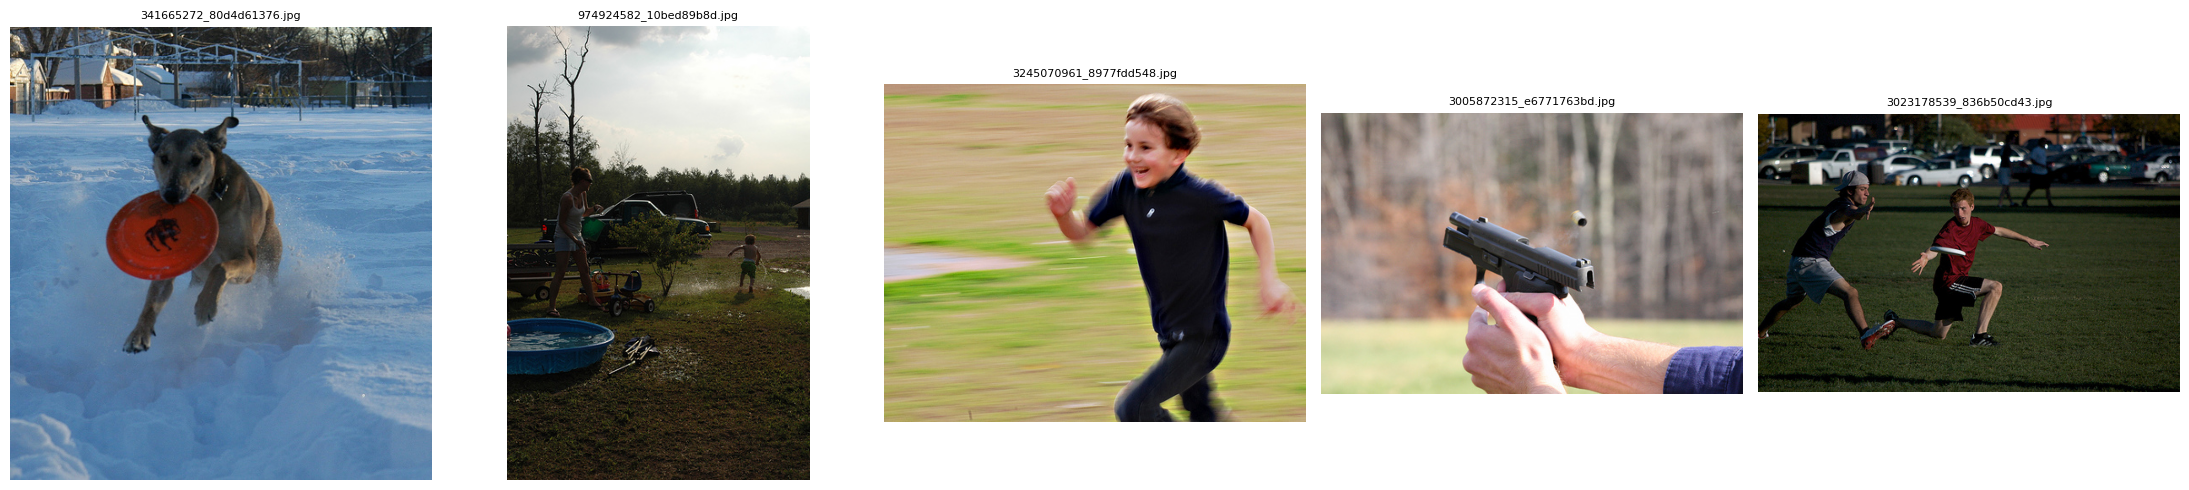

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, img_name in zip(axes, sample_images):
    img_path = os.path.join(image_folder, img_name)
    image = Image.open(img_path).convert("RGB")
    ax.imshow(image)
    ax.set_title(img_name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Qualitative Analysis: BLIP vs Human Captions

**Image 1 (341665272_80d4d61376.jpg) — Dog with Frisbee**
- BLIP caption: "a dog running in the snow with a fr frc"
- Observation: BLIP correctly identified the main subject (dog), action (running),
  and setting (snow). However, it failed to generate the word "Frisbee" correctly —
  it produced garbled/incomplete tokens ("fr frc"), likely because "Frisbee" is a
  less common word in its training vocabulary. This shows BLIP can struggle with
  specific object names outside its most frequent vocabulary.

**Image 2 (974924582_10bed89b8d.jpg) — Woman and Child by Pool**
- BLIP caption: "a woman and a child playing in a field"
- Observation: BLIP correctly identified the two subjects (woman, child) and general
  activity (playing), but got the setting wrong — human captions mention a "pool" or
  "paddling pool," while BLIP said "field." This shows a limitation in fine-grained
  scene/background recognition.

**Image 3 (3245070961_8977fdd548.jpg) — Boy Running**
- BLIP caption: "a boy running"
- Observation: This caption is accurate but very generic compared to the detailed
  human captions (which mention shirt color, smiling, speed). BLIP captures the
  core action correctly but lacks descriptive detail.

**Image 4 (3005872315_e6771763bd.jpg) — Man with Gun**
- BLIP caption: "a man holding a gun"
- Observation: Reasonably accurate and matches the human captions' core meaning
  (a person shooting a gun), though BLIP didn't capture the "close-up of hands"
  framing that most human captions emphasize.

**Image 5 (3023178539_836b50cd43.jpg) — Two People in a Field**
- BLIP caption: "two men playing frome"
- Observation: BLIP correctly identified "two men" and an activity, but again
  produced a garbled/nonsensical word ("frome") instead of a real word — similar
  to Image 1's issue. Human captions mention "Frisbee" here too, suggesting BLIP
  may consistently struggle with generating this specific word.

### Overall Summary
- BLIP performs reasonably well in **zero-shot** mode at identifying main subjects
  and actions (dog, boy, man, running, playing).
- It performs worse at **specific object names** (Frisbee appeared garbled in 2
  out of 5 images) and **fine-grained scene details** (e.g., pool vs. field).
- BLIP captions are noticeably **shorter and more generic** than human captions,
  which tend to include richer detail (colors, clothing, precise objects).
- These observations suggest that **fine-tuning BLIP on the Flickr8k training set**
  could improve accuracy on domain-specific vocabulary and descriptive richness —
  which will be explored in later stages of this internship.